<a href="https://colab.research.google.com/github/zaidan-khairiazhar/machine-learning-python/blob/main/ML_Method_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== INFORMASI DATASET ===
Jumlah baris dan kolom: (569, 31)

Distribusi kelas (0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64

=== Pengecekan Missing Values ===
Tidak ada missing value pada dataset.

Dataset dibagi menjadi data latih dan data uji.

Fitur berhasil di-scaling menggunakan StandardScaler.

=== HASIL AKURASI UNTUK SETIAP NILAI K ===
 k  akurasi_latih  akurasi_test
 1       1.000000      0.951049
 2       0.978873      0.937063
 3       0.976526      0.972028
 4       0.978873      0.958042
 5       0.969484      0.979021
 6       0.976526      0.972028
 7       0.974178      0.979021
 8       0.974178      0.972028
 9       0.969484      0.965035
10       0.971831      0.965035
11       0.971831      0.972028
12       0.969484      0.979021
13       0.971831      0.958042
14       0.971831      0.965035
15       0.969484      0.958042
16       0.969484      0.958042
17       0.964789      0.951049
18       0.967136      0.951049
19       0.964789

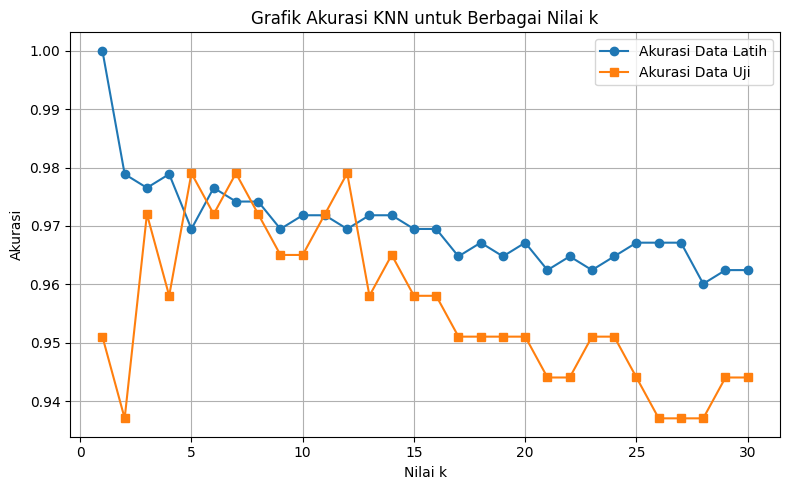

In [1]:
# ============================================================
# KLASIFIKASI KANKER PAYUDARA MENGGUNAKAN KNN
# ============================================================

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ============================================================
# 1. Memuat Dataset
# ============================================================

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target  # 0 = malignant, 1 = benign
nama_fitur = data.feature_names
nama_kelas = data.target_names

df = pd.concat([X, y.rename("target")], axis=1)

print("=== INFORMASI DATASET ===")
print("Jumlah baris dan kolom:", df.shape)
print("\nDistribusi kelas (0=malignant, 1=benign):")
print(df['target'].value_counts())

# ============================================================
# 2. Mengecek Missing Value
# ============================================================

print("\n=== Pengecekan Missing Values ===")
if df.isna().sum().sum() == 0:
    print("Tidak ada missing value pada dataset.")
else:
    print(df.isna().sum()[df.isna().sum() > 0])

# ============================================================
# 3. Train-Test Split
# ============================================================

X_latih, X_test, y_latih, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("\nDataset dibagi menjadi data latih dan data uji.")

# ============================================================
# 4. Standardisasi (Scaling)
# ============================================================

scaler = StandardScaler()
X_latih_skala = scaler.fit_transform(X_latih)
X_test_skala = scaler.transform(X_test)

print("\nFitur berhasil di-scaling menggunakan StandardScaler.")

# ============================================================
# 5. Eksperimen K dari 1 hingga 30
# ============================================================

daftar_k = range(1, 31)
akurasi_latih = []
akurasi_test = []

for k in daftar_k:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=1)
    model.fit(X_latih_skala, y_latih)

    pred_latih = model.predict(X_latih_skala)
    pred_test = model.predict(X_test_skala)

    akurasi_latih.append(accuracy_score(y_latih, pred_latih))
    akurasi_test.append(accuracy_score(y_test, pred_test))

# Membuat tabel hasil
hasil = pd.DataFrame({
    "k": daftar_k,
    "akurasi_latih": akurasi_latih,
    "akurasi_test": akurasi_test
})

print("\n=== HASIL AKURASI UNTUK SETIAP NILAI K ===")
print(hasil.to_string(index=False))

# ============================================================
# 6. Menentukan K Terbaik
# ============================================================

idx_terbaik = int(np.argmax(akurasi_test))
k_terbaik = daftar_k[idx_terbaik]

print(f"\nNilai k terbaik: {k_terbaik} dengan akurasi test = {akurasi_test[idx_terbaik]:.4f}")

# ============================================================
# 7. Evaluasi dengan K Terbaik
# ============================================================

model_terbaik = KNeighborsClassifier(n_neighbors=k_terbaik, n_jobs=1)
model_terbaik.fit(X_latih_skala, y_latih)
prediksi = model_terbaik.predict(X_test_skala)

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, prediksi))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, prediksi, target_names=list(nama_kelas)))

# ============================================================
# 8. Cross Validation
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skor_cv = cross_val_score(
    KNeighborsClassifier(n_neighbors=k_terbaik),
    scaler.fit_transform(X),
    y,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

print(f"\n=== 5-FOLD CROSS VALIDATION UNTUK k={k_terbaik} ===")
print(f"Mean Akurasi: {skor_cv.mean():.4f}")
print(f"Std Dev: {skor_cv.std():.4f}")

# ============================================================
# 9. Plot Akurasi vs K
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(daftar_k, akurasi_latih, marker='o', label='Akurasi Data Latih')
plt.plot(daftar_k, akurasi_test, marker='s', label='Akurasi Data Uji')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.title('Grafik Akurasi KNN untuk Berbagai Nilai k')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
